# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 04    |  |
| :-------------|:-------------|
| Daantje Bunschoten| 6375154
| Justin Sloots| 6541313 |
| Jelle Kooloos| 6532241 |
| Planning Groep: 04     |Tijdstip / Tijdspanne  |
|---|---|
|Aansluiten van generator en oscilloscoop  | 11:00 |
|Bekende condensator meten |11:30 |
|Zelf plaat condensator gemaakt |12:00|
|Zelfgemaakte plaat gemeten |12:45|
|Lunch pauze|12:45 - 13:45|
|Sensor plannen en maken|14:30|
|Meten aan de sensor |15:30|
|Verbetering| 16:00|
|Afronding en opruimen |17:30|


## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="Schets_condensator.jpg" alt="schets student 1" width="400"/>

In [1]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!
import numpy as np
epsilon_0=8.854e-12
epsilon_r = 2.7
def vlakkeplaat(A, d,epsilon_0,epsilon_r ):
    C = epsilon_0*epsilon_r * A / d
    return C

def capaciteitmeten(C,V_in, frequentie, weerstand):
    V_uit = C*(V_in*frequentie*2*np.pi*weerstand)
    return V_uit

# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.vV

In [2]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.
A= 0.1**2 #m
d_plastic= 0.08e-3 #m
d_papier= 0.09e-3 #m
d_karton = 1e-3
e_r_plastic = 2.4
e_r_papier = 3.5
e_r_karton = 2.7
#C = [vlakkeplaat(2.0), vlakkeplaat(4.7),vlakkeplaat(1.2)]

Capaciteit_plastic= vlakkeplaat(A,d_plastic,epsilon_0,e_r_plastic) 
Capaciteit_Papier= vlakkeplaat(A,d_papier,epsilon_0,e_r_papier)
Capaciteit_Karton = vlakkeplaat(A,d_karton,epsilon_0,e_r_karton)
#
# print(f"Berekende capaciteit plaatcondensator groep XX is {C[0]:.1f} pF")
print(Capaciteit_plastic)
print(Capaciteit_Papier)
print(Capaciteit_Karton)

Capaciteit_gemeten = capaciteitmeten(1.193662073189215e-10,0.6,1e5,1000)

print(Capaciteit_gemeten)

2.6561999999999996e-09
3.4432222222222228e-09
2.3905800000000003e-10
0.045


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![scope meting 1](foto_meting_condensator.jpg)
![scope meting 2](foto_opstelling_condensator.jpg)

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Daantje,Jelle, Justin        | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 04| 2.3905800000000003e-10 | 0.09012274278982427|0.045  |1.193662073189215e-10 |

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](Schetsen_ideen_sensor.jpg)


## Opdracht 3: Welke sensor gaan jullie maken?

Pas deze tekst aan: Wij gaan een sensor maken die massa meet.

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](Schets_sensor.jpg)

1.4829775022680558
3.0339886071194764e-11
2.1883804675135612e-11
4.3767609350271224e-11


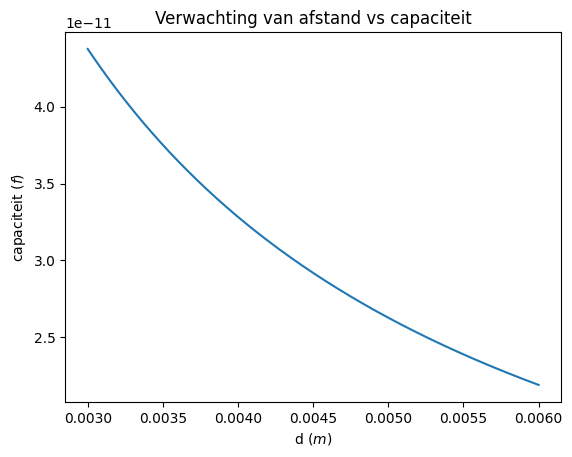

In [3]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit 

def vlakkeplaat(d,A,epsilon_0,epsilon_r ):
    C = epsilon_0*epsilon_r * A / d
    return C
def e_r(d,A,epsilon_0,C ):
    epsilon_r =  d *C /(epsilon_0 * A)
    return epsilon_r
def capaciteit(V_in,V_uit, frequentie, weerstand):
    C = V_uit/(V_in*frequentie*2*np.pi*weerstand)
    return C


d_0 = 6e-3 #m 
d_comp = 3e-3 #m
C_spons_0 = capaciteit(8,110e-3,100e3,1e3)
e_r_spons= e_r(d_0,A,epsilon_0,C_spons_0)
print(e_r_spons)
d_verwacht = np.linspace(d_0,d_comp,1000)
c_verwacht = vlakkeplaat(d_verwacht,A,epsilon_0,e_r_spons)
print(np.mean(c_verwacht))
print(min(c_verwacht))
print(max(c_verwacht))

plt.figure()
plt.plot(d_verwacht,c_verwacht)
plt.xlabel("d ($m$)")
plt.ylabel("capaciteit ($f$)")
plt.title("Verwachting van afstand vs capaciteit")
plt.show()



## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 21.8 pF |109.5mV |
| gemiddelde capaciteit| 30.3 pF | 152.2mV|
| maximale capaciteit| 43.8 pF |219.9mV|

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
![meting 1](foto_sensor_opstelling.jpg)
![meting 2](foto_meting_condensator.jpg)

## Opdracht 7: Plot de kalibratiegrafiek.

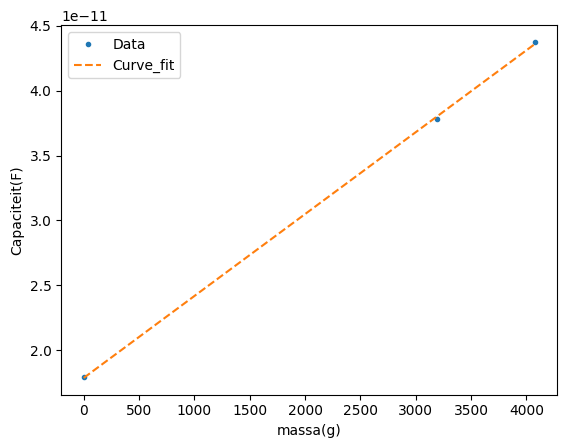

In [4]:
def Dikte(C,A,epsilon_0,epsilon_r ):
    d= epsilon_0*e_r_spons * A / C
    return d

V_uit = np.array([90e-3,190e-3,220e-3])
Capaciteit = capaciteit(8,V_uit,100e3,1e3)
d = Dikte(Capaciteit,A,epsilon_0,e_r_spons)
grotemassa1 =705.8+579.1+486.3+967.9+450.3+3.48
grotemassa2 = 705.8+579.1+486.3+967.9+450.3+3.48+880.79+0.486
massa= np.array([0,grotemassa1,grotemassa2])

def lijn(x,a,b):
   return a*x+b

var,cov = curve_fit(lijn,massa,Capaciteit)
x_fit = np.linspace(min(massa),max(massa))
y_fit = lijn(x_fit,*var)

plt.figure()
plt.plot(massa,Capaciteit,".",label="Data")
plt.plot(x_fit,y_fit,"--",label="Curve_fit")
plt.xlabel("massa(g)")
plt.ylabel("Capaciteit(F)")
plt.legend()
plt.show()

## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* We halen het midden van de spons eruit, waardoor er meer lucht is in het midden. Zo hopen we de algemene capaciteit van de condensator te verhogen.
* We gebruiken een bak voor het gewicht, zodat het evenwichtiger wordt verdeeld.

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
![foto sensor](foto_uiteindelijke_opstelling.jpg)

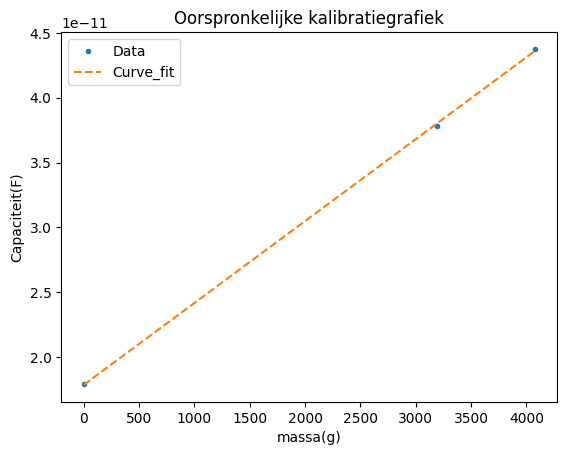

1.4829775022680558


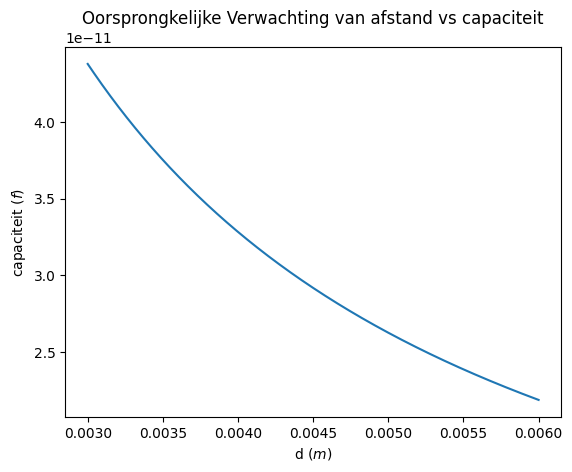

In [5]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbij
def Dikte(C,A,epsilon_0,epsilon_r ):
    d= epsilon_0*e_r_spons * A / C
    return d

V_uit = np.array([90e-3,190e-3,220e-3])
Capaciteit = capaciteit(8,V_uit,100e3,1e3)
d = Dikte(Capaciteit,A,epsilon_0,e_r_spons)
grotemassa1 =705.8+579.1+486.3+967.9+450.3+3.48
grotemassa2 = 705.8+579.1+486.3+967.9+450.3+3.48+880.79+0.486
massa= np.array([0,grotemassa1,grotemassa2])

def lijn(x,a,b):
   return a*x+b

var,cov = curve_fit(lijn,massa,Capaciteit)
x_fit = np.linspace(min(massa),max(massa))
y_fit = lijn(x_fit,*var)

plt.figure()
plt.plot(massa,Capaciteit,".",label="Data")
plt.plot(x_fit,y_fit,"--",label="Curve_fit")
plt.xlabel("massa(g)")
plt.ylabel("Capaciteit(F)")
plt.legend()
plt.title("Oorspronkelijke kalibratiegrafiek")
plt.show()


d_0 = 6e-3 #m 
d_comp = 3e-3 #m
C_spons_0 = capaciteit(8,110e-3,100e3,1e3)
e_r_spons= e_r(d_0,A,epsilon_0,C_spons_0)
print(e_r_spons)
d_verwacht = np.linspace(d_0,d_comp,1000)
c_verwacht = vlakkeplaat(d_verwacht,A,epsilon_0,e_r_spons)


plt.figure()
plt.plot(d_verwacht,c_verwacht)
plt.xlabel("d ($m$)")
plt.ylabel("capaciteit ($f$)")
plt.title("Oorsprongkelijke Verwachting van afstand vs capaciteit")
plt.show()


# Opnieuw de tabel met onze nieuwe opstelling
|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 18.9 pF |95.0 mV |
| gemiddelde capaciteit| 40.7 pF | 204.4 mV|
| maximale capaciteit| 113 pF |564 mV|

De relatieve permitiviteit van de nieuwe opstelling is 1.280753297413321


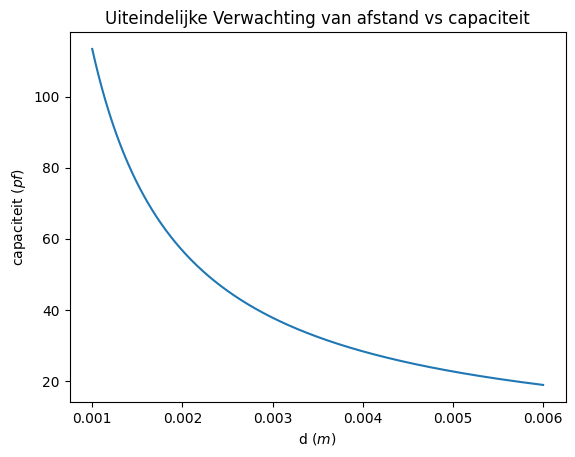

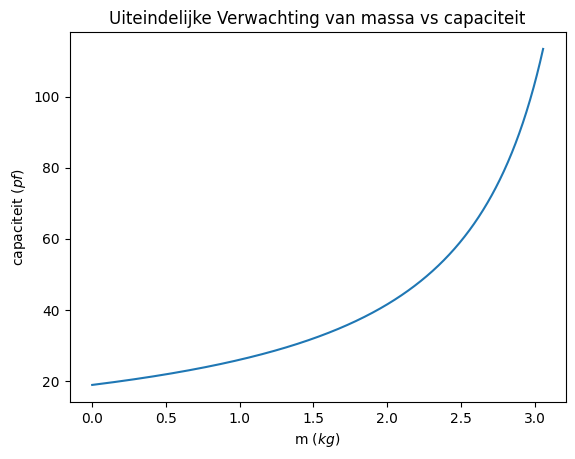

De minimale verwachte capaciteit is 18.899649492162574
De gemiddelde verwachte capaciteit is 40.661909535811866
De maximale verwachte capaciteit is 113.39789695297544


In [6]:
#d_0 blijft gelijk
d_0 = 6e-3 #m 
d_comp = 1e-3 #m

#van distance naar massa
def Veer(c_veer,u,g):
    m = c_veer * u /g
    return m

# parameters
u = d_0 - d_verwacht
c_veer = 10000
g = 9.81 #m/s^2

#E_r uitrekenen van de nieuwe opstelling
C_spons_0 = capaciteit(8,95e-3,100e3,1e3)
e_r_spons= e_r(d_0,A,epsilon_0,C_spons_0)
d_verwacht = np.linspace(d_0,d_comp,1000)
c_verwacht = vlakkeplaat(d_verwacht,A,epsilon_0,e_r_spons)*1e12
m_verwacht = Veer(c_veer,u,g)

#printen om te checken
print(f"De relatieve permitiviteit van de nieuwe opstelling is {e_r_spons}")

#plotten van nieuwe verwachtingsgrafiek
plt.figure()
plt.plot(d_verwacht,c_verwacht)
plt.xlabel("d ($m$)")
plt.ylabel("capaciteit ($pf$)")
plt.title("Uiteindelijke Verwachting van afstand vs capaciteit")
plt.show()

#plotten van verwachtingsgrafiek met m ipv d
plt.figure()
plt.plot(m_verwacht,c_verwacht)
plt.xlabel("m ($kg$)")
plt.ylabel("capaciteit ($pf$)")
plt.title("Uiteindelijke Verwachting van massa vs capaciteit")
plt.show()

#printen van verwachte waardes
print(f"De minimale verwachte capaciteit is {min(c_verwacht)}")
print(f"De gemiddelde verwachte capaciteit is {np.mean(c_verwacht)}")
print(f"De maximale verwachte capaciteit is {max(c_verwacht)}")

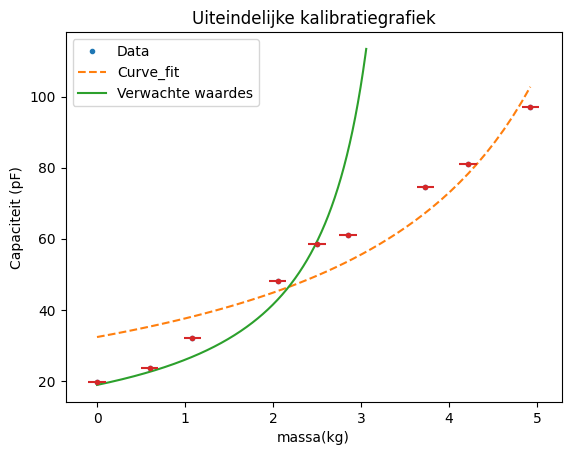

In [7]:

Capaciteit = np.array([19.7,23.6,32,48,58.4,61,74.5,81,97])
massa= np.array([0,
                597.1
                 ,597.1+486.3
                 ,597.1+486.3+967.9  ,2501.6,2849.6,3730.3,4216.3,4922.1 ]) *1e-3

#Poging tot het curve fitten met natuurkunde  
             
def Functie(x,c_1,c_2,c_3):
 return c_1/(c_2+c_3*x)
var,cov = curve_fit(Functie,massa,Capaciteit)
x_fit = np.linspace(min(massa),max(massa))
y_fit = Functie(x_fit,*var)
x_error = 0.1
y_error = 0 #y error wordt niet geplot, door de grootte waardoor de rest van de plot niet meer zichtbaar is



plt.figure()
plt.plot(massa,Capaciteit,".",label="Data")
plt.plot(x_fit,y_fit,"--",label="Curve_fit")
plt.plot(m_verwacht,c_verwacht, label="Verwachte waardes")
plt.xlabel("massa(kg)")
plt.ylabel("Capaciteit (pF)")
plt.errorbar(massa,Capaciteit,xerr=x_error,yerr=y_error,fmt='.')
plt.legend()
plt.title("Uiteindelijke kalibratiegrafiek")
plt.show()

## Opdracht 10: Vul hieronder de conclusie in.

Onze sensor is niet geschikt als weegschaal, want de waardes wijken te veel af van de curvefit en de verwachte waardes. Dit komt waarschijnlijk doordat de spons niet werkt als een perfecte veer, en nadat er meer massa op wordt gelegd minder snel indrukt. Onze verbetering uit de iteratiestap heeft wel een verbetering geleverd. Want de capaciteit viel door de iteratie binnen de gewenste waardes, wat betekend dat we precieser konden meten.
Ja, er zit een significant verschil tussen de metingen omdat de spons niet werkt als een fysische veer. Wat betekend dat de verwachte waardes en de echte waardes zeer uit elkaar lopen.
De vlakkeplaat formule klopt niet voor deze sensor omdat de verwachte waardes en de verkregen waardes te veel uiteenlopen


## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.
#### Voeg hier de foto's van je sensoren in actie in.
![meting 1](foto_sensor_opstelling.jpg)
![meting 2](foto_meting_condensator.jpg)
![foto sensor](foto_uiteindelijke_opstelling.jpg)
![uitgewerkte schets](Schets_sensor.jpg)

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.
![meting 1](foto_sensor_opstelling.jpg)
![meting 2](foto_meting_condensator.jpg)
![foto sensor](foto_uiteindelijke_opstelling.jpg)

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.

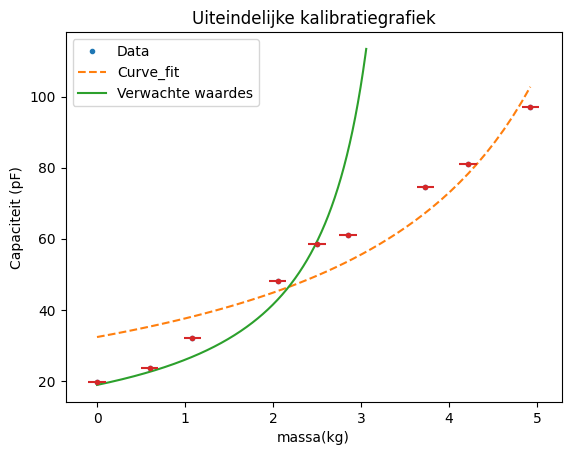

In [8]:

Capaciteit = np.array([19.7,23.6,32,48,58.4,61,74.5,81,97])
massa= np.array([0,
                597.1
                 ,597.1+486.3
                 ,597.1+486.3+967.9  ,2501.6,2849.6,3730.3,4216.3,4922.1 ]) *1e-3

#Poging tot het curve fitten met natuurkunde  
             
def Functie(x,c_1,c_2,c_3):
 return c_1/(c_2+c_3*x)
var,cov = curve_fit(Functie,massa,Capaciteit)
x_fit = np.linspace(min(massa),max(massa))
y_fit = Functie(x_fit,*var)
x_error = 0.1
y_error = 0 #y error wordt niet geplot, door de grootte waardoor de rest van de plot niet meer zichtbaar is



plt.figure()
plt.plot(massa,Capaciteit,".",label="Data")
plt.plot(x_fit,y_fit,"--",label="Curve_fit")
plt.plot(m_verwacht,c_verwacht, label="Verwachte waardes")
plt.xlabel("massa(kg)")
plt.ylabel("Capaciteit (pF)")
plt.errorbar(massa,Capaciteit,xerr=x_error,yerr=y_error,fmt='.')
plt.legend()
plt.title("Uiteindelijke kalibratiegrafiek")
plt.show()

De relatieve permitiviteit van de nieuwe opstelling is 1.280753297413321


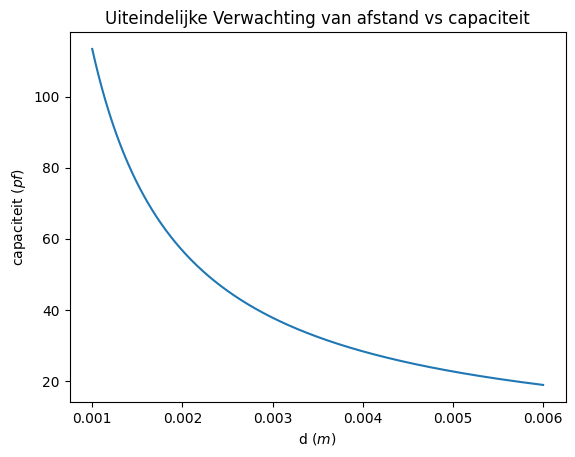

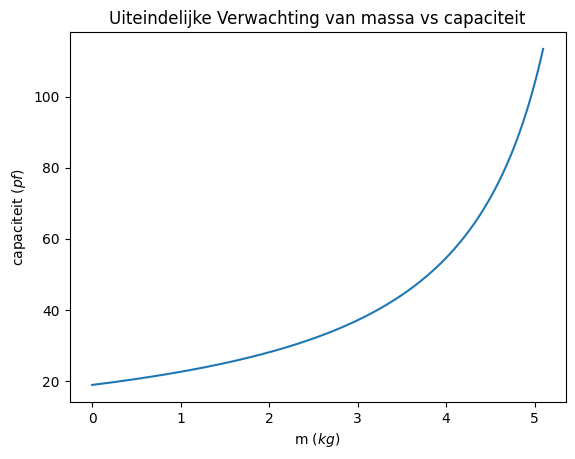

De minimale verwachte capaciteit is 18.899649492162574
De gemiddelde verwachte capaciteit is 40.661909535811866
De maximale verwachte capaciteit is 113.39789695297544


In [9]:
#d_0 blijft gelijk
d_0 = 6e-3 #m 
d_comp = 1e-3 #m

#van distance naar massa
def Veer(c_veer,u,g):
    m = c_veer * u /g
    return m

# parameters
u = d_0 - d_verwacht
c_veer = 10000
g = 9.81 #m/s^2

#E_r uitrekenen van de nieuwe opstelling
C_spons_0 = capaciteit(8,95e-3,100e3,1e3)
e_r_spons= e_r(d_0,A,epsilon_0,C_spons_0)
d_verwacht = np.linspace(d_0,d_comp,1000)
c_verwacht = vlakkeplaat(d_verwacht,A,epsilon_0,e_r_spons)*1e12
m_verwacht = Veer(c_veer,u,g)

#printen om te checken
print(f"De relatieve permitiviteit van de nieuwe opstelling is {e_r_spons}")

#plotten van nieuwe verwachtingsgrafiek
plt.figure()
plt.plot(d_verwacht,c_verwacht)
plt.xlabel("d ($m$)")
plt.ylabel("capaciteit ($pf$)")
plt.title("Uiteindelijke Verwachting van afstand vs capaciteit")
plt.show()

#plotten van verwachtingsgrafiek met m ipv d
plt.figure()
plt.plot(m_verwacht,c_verwacht)
plt.xlabel("m ($kg$)")
plt.ylabel("capaciteit ($pf$)")
plt.title("Uiteindelijke Verwachting van massa vs capaciteit")
plt.show()

#printen van verwachte waardes
print(f"De minimale verwachte capaciteit is {min(c_verwacht)}")
print(f"De gemiddelde verwachte capaciteit is {np.mean(c_verwacht)}")
print(f"De maximale verwachte capaciteit is {max(c_verwacht)}")